# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           2.64e-20
Time:                        20:43:31   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             760.3
Df Residuals:                     239   BIC:                             777.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1999      0.242      4.

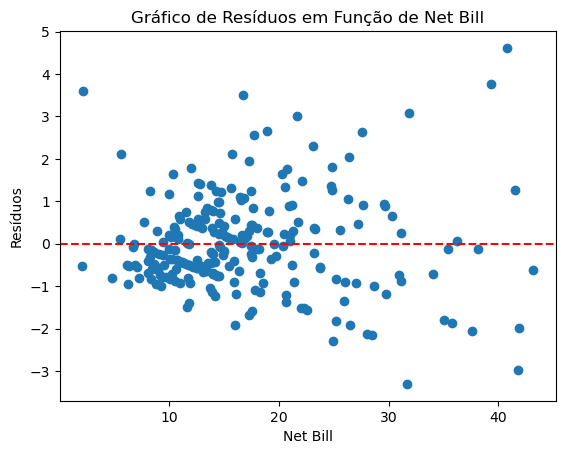

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     25.06
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           2.41e-17
Time:                        20:43:32   Log-Likelihood:                -382.22
No. Observations:                 244   AIC:                             774.4
Df Residuals:                     239   BIC:                             791.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.3107      0.469     -2.

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import patsy
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar o dataset "tips"
tips = sns.load_dataset("tips")

# 2. Criar a coluna net_bill
tips['net_bill'] = tips['total_bill'] - tips['tip']

# Criar a matriz de design e a matriz y
y, X = patsy.dmatrices('tip ~ sex + smoker + time + net_bill', data=tips, return_type='dataframe')

# 3. Ajustar o modelo de regressão
model = sm.OLS(y, X).fit()

# Exibir o resumo do modelo
print(model.summary())

# 4. Remover variáveis não significativas
# Vamos considerar um nível de significância de 0.05
significant_vars = model.pvalues[model.pvalues < 0.05].index
X_significant = X[significant_vars]

# Ajustar o modelo novamente com variáveis significativas
model_significant = sm.OLS(y, X_significant).fit()
print(model_significant.summary())

# 5. Gráfico de resíduos em função de net_bill
residuals = model_significant.resid
plt.scatter(tips['net_bill'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Net Bill')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos em Função de Net Bill')
plt.show()

# 6. Testar transformações em net_bill
# Transformação logarítmica
tips['log_net_bill'] = np.log(tips['net_bill'])
y_log, X_log = patsy.dmatrices('tip ~ sex + smoker + time + log_net_bill', data=tips, return_type='dataframe')
model_log = sm.OLS(y_log, X_log).fit()
print(model_log.summary())

# Testar um polinômio de net_bill
tips['net_bill_squared'] = tips['net_bill'] ** 2
y_poly, X_poly = patsy.dmatrices('tip ~ sex + smoker + time + net_bill + net_bill_squared', data=tips, return_type='dataframe')
model_poly = sm.OLS(y_poly, X_poly).fit()
print(model_poly.summary())

# 7. Comparar os modelos
print("Modelo Original:")
print(model_significant.summary())
print("\nModelo Logarítmico:")
print(model_log.summary())
print("\nModelo Polinomial:")
print(model_poly.summary())

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     27.25
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           1.21e-18
Time:                        20:45:20   Log-Likelihood:                -97.419
No. Observations:                 244   AIC:                             204.8
Df Residuals:                     239   BIC:                             222.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4504      0.078      5.

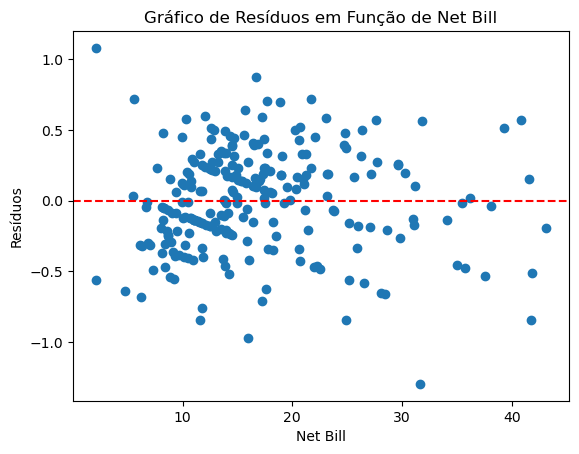

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     28.12
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           3.79e-19
Time:                        20:45:20   Log-Likelihood:                -96.213
No. Observations:                 244   AIC:                             202.4
Df Residuals:                     239   BIC:                             219.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4185      0.145     -2.

In [5]:
# 1. Carregar o dataset "tips"
tips = sns.load_dataset("tips")

# Criar a coluna net_bill
tips['net_bill'] = tips['total_bill'] - tips['tip']

# 2. Criar a matriz de design e a matriz y para o log de tip
y, X = patsy.dmatrices('np.log(tip) ~ sex + smoker + time + net_bill', data=tips, return_type='dataframe')

# 3. Ajustar o modelo de regressão
model = sm.OLS(y, X).fit()

# Exibir o resumo do modelo
print(model.summary())

# 4. Remover variáveis não significativas
# Vamos considerar um nível de significância de 0.05
significant_vars = model.pvalues[model.pvalues < 0.05].index
X_significant = X[significant_vars]

# Ajustar o modelo novamente com variáveis significativas
model_significant = sm.OLS(y, X_significant).fit()
print(model_significant.summary())

# 5. Gráfico de resíduos em função de net_bill
residuals = model_significant.resid
plt.scatter(tips['net_bill'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Net Bill')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos em Função de Net Bill')
plt.show()

# 6. Testar transformações em net_bill
# Transformação logarítmica
tips['log_net_bill'] = np.log(tips['net_bill'])
y_log, X_log = patsy.dmatrices('np.log(tip) ~ sex + smoker + time + log_net_bill', data=tips, return_type='dataframe')
model_log = sm.OLS(y_log, X_log).fit()
print(model_log.summary())

# Testar um polinômio de net_bill
tips['net_bill_squared'] = tips['net_bill'] ** 2
y_poly, X_poly = patsy.dmatrices('np.log(tip) ~ sex + smoker + time + net_bill + net_bill_squared', data=tips, return_type='dataframe')
model_poly = sm.OLS(y_poly, X_poly).fit()
print(model_poly.summary())

# 7. Comparar os modelos
print("Modelo Significativo:")
print(model_significant.summary())
print("\nModelo Logarítmico:")
print(model_log.summary())
print("\nModelo Polinomial:")
print(model_poly.summary())

# 8. Calcular o coeficiente de determinação (R²) na escala original
predicted_log_tip = model_significant.predict(X_significant)
predicted_tip = np.exp(predicted_log_tip)  # Transformar de volta para a escala original

# Calcular R² na escala original
r_squared = 1 - (np.sum((tips['tip'] - predicted_tip) ** 2) / np.sum((tips['tip'] - tips['tip'].mean()) ** 2))
print(f"Coeficiente de Determinação (R²) na escala original: {r_squared}")


### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import patsy

df = pd.read_csv('C:/Users/fabio/Documents/EBAC/Modulo12/tarefa3/previsao_de_renda.csv')

df.head()

,Unnamed: 0,data_ref,id_cliente,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,0,2015-01-01,15056,F,False,True,0,Empresário,Secundário,Solteiro,Casa,26,6.602740,1.0,8060.34
1,1,2015-01-01,9968,M,True,True,0,Assalariado,Superior completo,Casado,Casa,28,7.183562,2.0,1852.15
2,2,2015-01-01,4312,F,True,True,0,Empresário,Superior completo,Casado,Casa,35,0.838356,2.0,2253.89
3,3,2015-01-01,10639,F,False,True,1,Servidor público,Superior completo,Casado,Casa,30,4.846575,3.0,6600.77
4,4,2015-01-01,7064,M,True,False,0,Assalariado,Secundário,Solteiro,Governamental,33,4.293151,1.0,6475.97


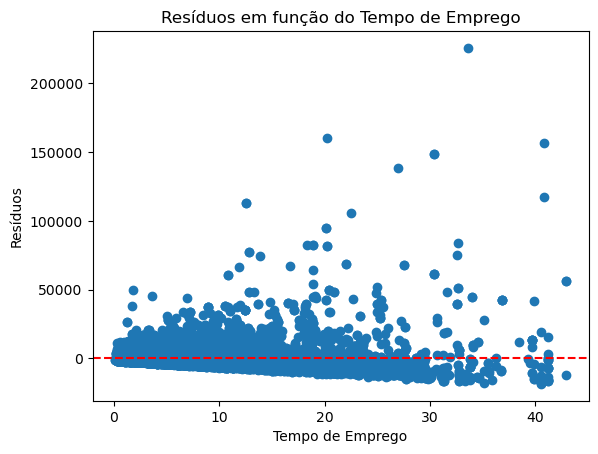

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     2162.
Date:                Tue, 26 Nov 2024   Prob (F-statistic):               0.00
Time:                        20:49:12   Log-Likelihood:            -1.2963e+05
No. Observations:               12427   AIC:                         2.593e+05
Df Residuals:                   12425   BIC:                         2.593e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2177.9041    112.212     19.409      0.000    1957.951    2397.857
tempo_emprego   510.0119     10.968     46.501      0.000     488.513     531.510
==============================================================================
Omnibus:                    17028.827   Durbin-Watson:                   2.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7679294.474
Skew:                           7.717   Prob(JB):                         0.00
Kurtosis:                     123.800   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
# Ajustar o modelo de regressão linear simples para explicar renda por tempo_emprego
# Remover dados com valores nulos em 'renda' ou 'tempo_emprego'
dados_filtrados = df.dropna(subset=['renda', 'tempo_emprego'])

# Ajustar o modelo
modelo_simples = ols('renda ~ tempo_emprego', data=dados_filtrados).fit()

# Resumo do modelo
resumo_simples = modelo_simples.summary()

# Análise de resíduos
residuos_simples = modelo_simples.resid

# Gráfico de resíduos em função de tempo_emprego
plt.scatter(dados_filtrados['tempo_emprego'], residuos_simples)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Tempo de Emprego")
plt.ylabel("Resíduos")
plt.title("Resíduos em função do Tempo de Emprego")
plt.show()

# Mostrar o resumo do modelo
resumo_simples


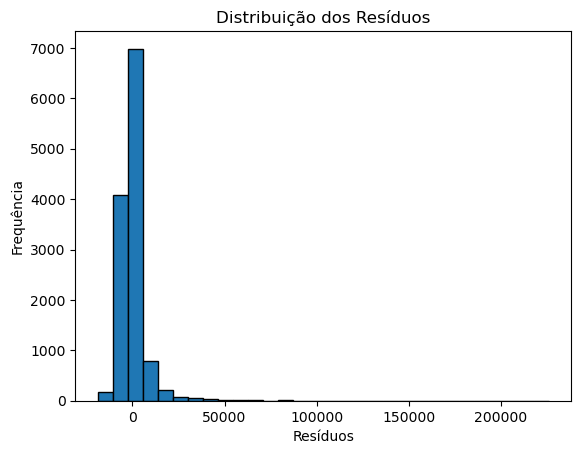

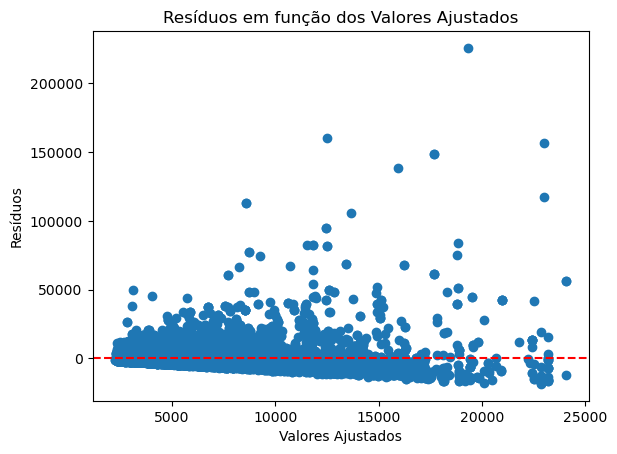

Shapiro-Wilk Teste de Normalidade:
Estatística W: 0.5718610503569623, p-valor: 1.7842524329278291e-99

Teste de Breusch-Pagan para Heterocedasticidade:
LM-Statistic: 322.63813716433435, p-valor: 3.857137321881389e-72


C:\Users\fabio\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12427.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\fabio\AppData\Local\Temp\ipykernel_16068\653369806.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_filtrados['log_renda'] = np.log(dados_filtrados['renda'])


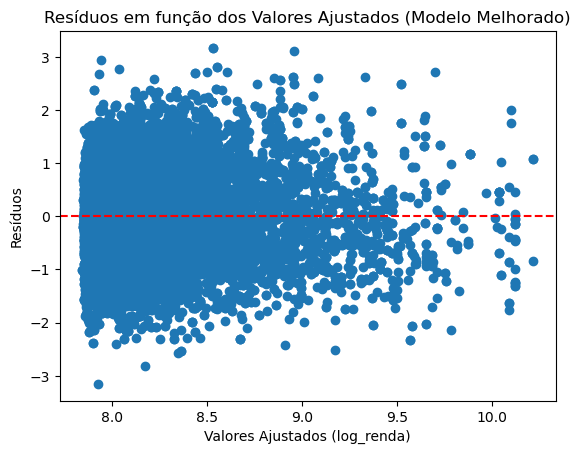

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     2564.
Date:                Tue, 26 Nov 2024   Prob (F-statistic):               0.00
Time:                        20:50:01   Log-Likelihood:                -15150.
No. Observations:               12427   AIC:                         3.030e+04
Df Residuals:                   12425   BIC:                         3.032e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.8384      0.011    699.851

In [12]:
# Histograma dos resíduos para verificar normalidade
plt.hist(residuos_simples, bins=30, edgecolor='black')
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")
plt.show()

# Gráfico de resíduos vs. valores ajustados
plt.scatter(modelo_simples.fittedvalues, residuos_simples)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.title("Resíduos em função dos Valores Ajustados")
plt.show()

# Teste de normalidade dos resíduos (Shapiro-Wilk)
from scipy.stats import shapiro
shapiro_test = shapiro(residuos_simples)
print("Shapiro-Wilk Teste de Normalidade:")
print(f"Estatística W: {shapiro_test.statistic}, p-valor: {shapiro_test.pvalue}")

# Verificar heterocedasticidade com teste de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuos_simples, modelo_simples.model.exog)
print("\nTeste de Breusch-Pagan para Heterocedasticidade:")
print(f"LM-Statistic: {bp_test[0]}, p-valor: {bp_test[1]}")

# Sugestão de melhorias
# - Transformação da variável dependente: Logarítmica
dados_filtrados['log_renda'] = np.log(dados_filtrados['renda'])

# Reajustar o modelo com log(renda)
modelo_melhorado = ols('log_renda ~ tempo_emprego', data=dados_filtrados).fit()

# Resumo do modelo melhorado
resumo_melhorado = modelo_melhorado.summary()

# Análise de resíduos do modelo melhorado
residuos_melhorados = modelo_melhorado.resid

# Gráfico de resíduos para o modelo melhorado
plt.scatter(modelo_melhorado.fittedvalues, residuos_melhorados)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados (log_renda)")
plt.ylabel("Resíduos")
plt.title("Resíduos em função dos Valores Ajustados (Modelo Melhorado)")
plt.show()

# Exibir o resumo do modelo melhorado
print(resumo_melhorado)


Melhorias possíveis:

Transformação logarítmica:

Pode lidar com a heterocedasticidade nos resíduos, tornando-os mais homogêneos.
Aplica-se à variável dependente (renda) para estabilizar a variância.

Modelos não lineares:

Adicionar termos polinomiais ou interações pode capturar padrões mais complexos.

Outliers:

Verificar se há outliers extremos que podem estar influenciando o modelo.

Variáveis adicionais:

Incluir outras variáveis explicativas relevantes, se houver, pode melhorar o ajuste do modelo.

In [14]:
variaveis_explicativas = '+'.join(
    col for col in dados_filtrados.columns if col not in ['renda', 'log_renda', 'id_cliente', 'Unnamed: 0']
)

# Fórmula do modelo múltiplo
formula_multipla = f'log_renda ~ {variaveis_explicativas}'

# Ajustar o modelo de regressão múltipla
modelo_multipla = ols(formula_multipla, data=dados_filtrados).fit()

# Resumo do modelo múltiplo
resumo_multipla = modelo_multipla.summary()

# Exibir o resumo do modelo ajustado
print(resumo_multipla)

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     182.5
Date:                Tue, 26 Nov 2024   Prob (F-statistic):               0.00
Time:                        20:51:04   Log-Likelihood:                -13554.
No. Observations:               12427   AIC:                         2.719e+04
Df Residuals:                   12388   BIC:                         2.748e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     2162.
Date:                Tue, 26 Nov 2024   Prob (F-statistic):               0.00
Time:                        20:57:45   Log-Likelihood:            -1.2963e+05
No. Observations:               12427   AIC:                         2.593e+05
Df Residuals:                   12425   BIC:                         2.593e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2177.9041    112.212     19.409

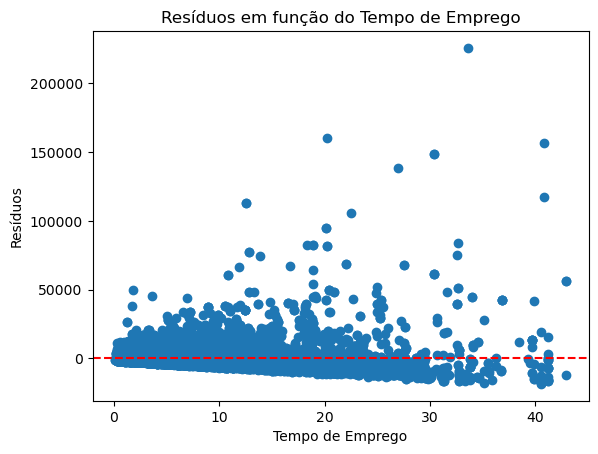

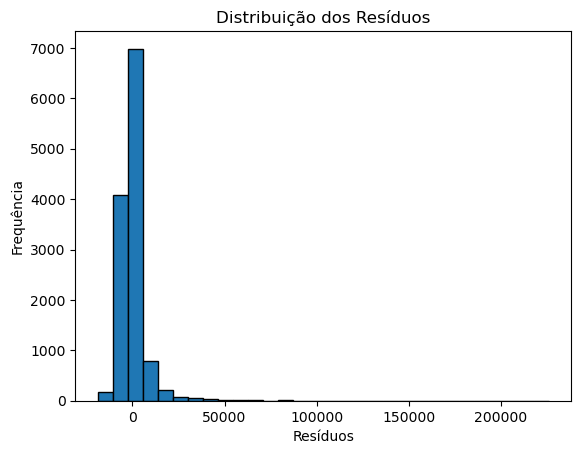

Shapiro-Wilk Teste de Normalidade:
Estatística W: 0.5718610503569623, p-valor: 1.7842524329278291e-99

Teste de Breusch-Pagan para Heterocedasticidade:
LM-Statistic: 322.63813716433435, p-valor: 3.857137321881389e-72
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     2564.
Date:                Tue, 26 Nov 2024   Prob (F-statistic):               0.00
Time:                        20:57:46   Log-Likelihood:                -15150.
No. Observations:               12427   AIC:                         3.030e+04
Df Residuals:                   12425   BIC:                         3.032e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                   

C:\Users\fabio\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12427.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\fabio\AppData\Local\Temp\ipykernel_16068\2661239222.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_filtrados['log_renda'] = np.log(dados_filtrados['renda'])


KeyError: 'Unnamed: 0'

In [32]:
# Remover dados com valores nulos em 'renda' ou 'tempo_emprego'
dados_filtrados = df.dropna(subset=['renda', 'tempo_emprego'])

# Ajustar o modelo de regressão linear simples
modelo_simples = ols('renda ~ tempo_emprego', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_simples.summary())

# Análise de resíduos
residuos_simples = modelo_simples.resid

# Gráfico de resíduos em função de tempo_emprego
plt.scatter(dados_filtrados['tempo_emprego'], residuos_simples)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Tempo de Emprego")
plt.ylabel("Resíduos")
plt.title("Resíduos em função do Tempo de Emprego")
plt.show()

# Histograma dos resíduos
plt.hist(residuos_simples, bins=30, edgecolor='black')
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")
plt.show()

# Teste de normalidade dos resíduos (Shapiro-Wilk)
shapiro_test = shapiro(residuos_simples)
print("Shapiro-Wilk Teste de Normalidade:")
print(f"Estatística W: {shapiro_test.statistic}, p-valor: {shapiro_test.pvalue}")

# Verificar heterocedasticidade com teste de Breusch-Pagan
bp_test = het_breuschpagan(residuos_simples, modelo_simples.model.exog)
print("\nTeste de Breusch-Pagan para Heterocedasticidade:")
print(f"LM-Statistic: {bp_test[0]}, p-valor: {bp_test[1]}")

# Transformação da variável dependente: Logarítmica
dados_filtrados['log_renda'] = np.log(dados_filtrados['renda'])

# Ajustar o modelo com log(renda)
modelo_melhorado = ols('log_renda ~ tempo_emprego', data=dados_filtrados).fit()

# Resumo do modelo melhorado
print(modelo_melhorado.summary())

# Identificar variáveis não significativas (p > 0.05)
variaveis_explicativas = [col for col in dados_filtrados.columns if col not in ['renda', 'log_renda', 'id_cliente']]
variaveis_significativas = [var for var in variaveis_explicativas if modelo_melhorado.pvalues[var] <= 0.05]

# Criar nova fórmula com variáveis significativas
nova_formula = f'log_renda ~ {" + ".join(variaveis_significativas)}'

# Ajustar o modelo com as variáveis significativas
modelo_ajustado = ols(nova_formula, data=dados_filtrados).fit()

# Resumo do modelo ajustado
print(modelo_ajustado.summary())

In [34]:
# Análise de resíduos para o modelo ajustado
residuos = modelo_significativo.resid

# Histograma dos resíduos para verificar a normalidade
plt.hist(residuos, bins=30, edgecolor='black')
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")
plt.show()

# Gráfico de resíduos vs. valores ajustados
plt.scatter(modelo_significativo.fittedvalues, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.title("Resíduos em função dos Valores Ajustados")
plt.show()

# Teste de normalidade dos resíduos (Shapiro-Wilk)
from scipy.stats import shapiro
shapiro_test = shapiro(residuos)
print("Teste de Normalidade (Shapiro-Wilk):")
print(f"Estatística W: {shapiro_test.statistic}, p-valor: {shapiro_test.pvalue}")

# Verificar heterocedasticidade com o teste de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuos, modelo_significativo.model.exog)
print("\nTeste de Breusch-Pagan para Heterocedasticidade:")
print(f"LM-Statistic: {bp_test[0]}, p-valor: {bp_test[1]}")

# Avaliar a qualidade do ajuste pelo R² e AIC
print("\nQualidade do Ajuste:")
print(f"R²: {modelo_significativo.rsquared}")
print(f"AIC: {modelo_significativo.aic}")


NameError: name 'modelo_significativo' is not defined


Para realizar uma análise de resíduos e avaliar a qualidade do ajuste em meu modelo de regressão, sigo alguns passos fundamentais:

Ajuste do Modelo: Primeiro, ajusto meu modelo de regressão aos dados. Isso pode ser feito utilizando métodos como a regressão linear.

Cálculo dos Resíduos: Calculo os resíduos como a diferença entre os valores observados e os valores previstos pelo modelo. Eles são essenciais para avaliar a qualidade do ajuste.

Verificação das Premissas: Verifico as premissas do modelo de regressão, incluindo:

Normalidade dos Resíduos: Os resíduos devem seguir uma distribuição normal. Avalio isso visualmente através de um histograma ou um gráfico Q-Q.
Homoscedasticidade: A variância dos resíduos deve ser constante em todos os níveis das variáveis independentes. Gráficos de resíduos versus valores ajustados me ajudam a identificar padrões.
Independência dos Resíduos: Os resíduos não devem apresentar autocorrelação, e isso pode ser verificado usando gráficos de autocorrelação.
Gráficos de Resíduos:

Gráfico de Resíduos vs. Valores Ajustados: Um gráfico que mostra os resíduos em função dos valores ajustados pode revelar padrões. Idealmente, espero que os resíduos estejam distribuídos aleatoriamente em torno de zero.
Histograma dos Resíduos: Um histograma me ajuda a visualizar a distribuição dos resíduos e verificar a normalidade.
Testes Estatísticos:

Teste de Shapiro-Wilk: Utilizo este teste para verificar a normalidade dos resíduos. Um p-valor menor que 0.05 indica que posso rejeitar a hipótese de normalidade.
Teste de Breusch-Pagan: Uso este teste para verificar a homocedasticidade. Um p-valor menor que 0.05 sugere a presença de heterocedasticidade.
Interpretação dos Resultados:

Qualidade do Ajuste: Avalio o R-quadrado do modelo, que indica a proporção da variância na variável dependente que é explicada pelas variáveis independentes. Um R-quadrado mais alto geralmente indica um melhor ajuste.
Significância dos Coeficientes: Verifico os p-valores dos coeficientes do modelo. Coeficientes com p-valores menores que 0.05 são considerados estatisticamente significativos.
Ajustes Necessários: Se a análise de resíduos indicar problemas, considero:

Transformações de variáveis (por exemplo, logaritmos).
Inclusão de termos quadráticos ou interações.
Uso de modelos não lineares se a relação entre as variáveis não for linear.
Conclusão
A análise de resíduos é uma etapa crucial na avaliação da qualidade do ajuste do meu modelo de regressão. Ela me fornece insights sobre a adequação do modelo e ajuda a identificar áreas que podem ser melhoradas para obter previsões mais precisas e confiáveis.